# 01 MCDI505 — Análisis de series de tiempo

## Consumo eléctrico del litoral


**Integrantes:** Luis Rodrigo Espinoza  
**Docente:** Dr. Harvey Jezlid Rosas Quintero  
**Datos:** `data/raw/consumo_electrico_litoral.csv` (desde la raíz del proyecto)  
**Figuras:** `results/figures/` (desde la raíz del proyecto)  
**Fecha:** 02 de octubre de 2026

# 02 Introducción y descripción del dataset

**Propósito.**  

Analizar exploratoriamente una serie temporal de consumo eléctrico mensual, identificando sus principales patrones estructurales mediante visualización, descomposición y análisis de autocorrelación. El objetivo es reconocer la presencia de tendencia, estacionalidad, ciclos y variaciones residuales, y relacionar estos comportamientos con las funciones ACF y PACF como base para un modelamiento posterior.
Descripción del dataset. Se utiliza el conjunto de datos consumo_electrico_litoral.csv, compuesto por 120 observaciones mensuales comprendidas entre enero de 2015 y diciembre de 2024. El dataset contiene las variables fecha, consumo_gwh, clientes_comerciales, temperatura_media_c y dias_habiles. Para este análisis, la variable principal corresponde a consumo_gwh, que representa el consumo eléctrico mensual expresado en GWh. 

La serie presenta tres valores faltantes en dicha variable, los cuales deberán ser tratados antes de aplicar la descomposición y el análisis de autocorrelación.


# 03 Carga y preparación de los datos

In [19]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# localizar la raíz del proyecto desde el directorio de ejecución
project_root = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "data/raw/consumo_electrico_litoral.csv").is_file()
    ),
    None,
)
if project_root is None:
    raise FileNotFoundError("No se encontró data/raw/consumo_electrico_litoral.csv")

# crear la carpeta de salida para las figuras
figures_dir = project_root / "results" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# leer el archivo CSV y parsear la columna de fechas
data_path = project_root / "data" / "raw" / "consumo_electrico_litoral.csv"
df = pd.read_csv(data_path, parse_dates=["fecha"])
# establecer la columna de fechas como índice y cambiar la frecuencia a mensual
df = df.set_index("fecha").asfreq("MS")
# mostrar las primeras filas del DataFrame
df.head()

,consumo_gwh,clientes_comerciales,temperatura_media_c,dias_habiles
fecha,,,,
2015-01-01,108.32,41827,19.6,22
2015-02-01,94.71,41918,18.7,20
2015-03-01,89.52,42045,16.5,22
2015-04-01,82.24,42129,13.3,22
2015-05-01,82.60,42242,12.0,21


### información general del DataFrame

In [14]:
# información general del DataFrame
df.info()
# estadísticas descriptivas del DataFrame

print("Valores faltantes por columna:")
display(df.isnull().sum())

print("\nEstadísticas descriptivas:")
display(df.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120 entries, 2015-01-01 to 2024-12-01
Freq: MS
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   consumo_gwh           117 non-null    float64
 1   clientes_comerciales  120 non-null    int64  
 2   temperatura_media_c   120 non-null    float64
 3   dias_habiles          120 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 4.7 KB
Valores faltantes por columna:


consumo_gwh             3
clientes_comerciales    0
temperatura_media_c     0
dias_habiles            0
dtype: int64


Estadísticas descriptivas:


,consumo_gwh,clientes_comerciales,temperatura_media_c,dias_habiles
count,117.000000,120.000000,120.000000,120.000000
mean,104.612137,49389.591667,15.700000,21.741667
std,13.645166,4581.499820,3.186236,0.948203
min,73.190000,41827.000000,10.500000,20.000000
25%,95.740000,45269.500000,12.600000,21.000000
50%,102.940000,49761.500000,15.350000,22.000000
75%,114.880000,53472.250000,18.400000,22.000000
max,145.820000,56885.000000,21.700000,23.000000


# 04 Exploración y gráfico de la serie**

### Esta serie tiene 3 valores faltantes, podemos tratarlos mediante interpolación lineal



In [15]:

# mediante interpolación lineal, podemos tratar los valores faltantes de la serie

serie = df["consumo_gwh"].interpolate("time")

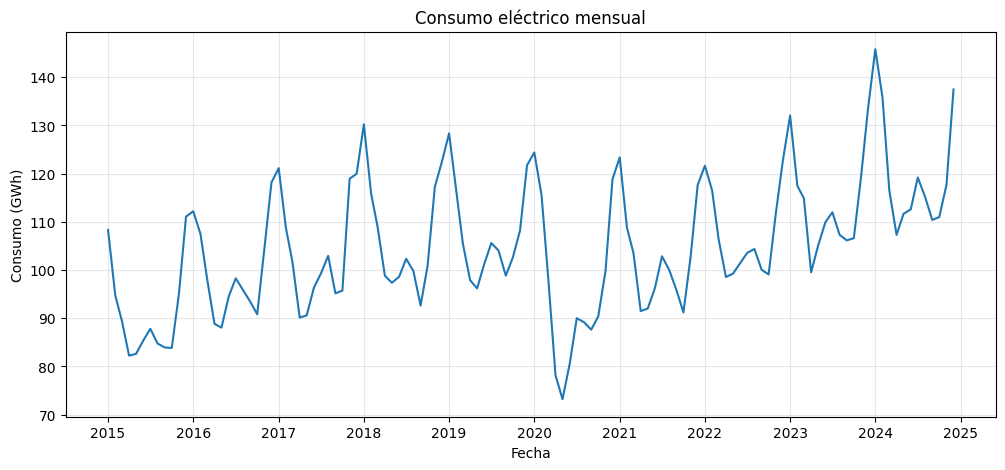

In [16]:
# Exploración y gráfico de la serie

# figura de tamaño 12x5
plt.figure(figsize=(12, 5))
# gráfico de la serie
plt.plot(serie)
# título y etiquetas de los ejes
plt.title("Consumo eléctrico mensual")
# etiquetas de los ejes
plt.xlabel("Fecha")
# etiquetas de los ejes
plt.ylabel("Consumo (GWh)")
# mostrar la cuadrícula
plt.grid(alpha=0.3)
# guardar y mostrar el gráfico
plt.savefig(figures_dir / "consumo_electrico_mensual.png", dpi=300, bbox_inches="tight")
plt.show()


### ¿Sube o baja a largo plazo?

Sube. Se observa una tendencia general creciente entre 2015 y 2024.

### ¿Se repiten patrones aproximadamente cada 12 meses?

Sí. Hay picos y caídas que se repiten de forma similar cada año.
### ¿Ves períodos anormales?

Sí. Destaca una caída fuerte alrededor de 2020 y un pico muy alto en 2024.
### ¿La amplitud parece aumentar con el nivel?

Sí, levemente. Hacia los últimos años las diferencias entre máximos y mínimos parecen mayores.
### ¿Parece haber ciclos o cambios de nivel?

Sí. Hay una disminución marcada en 2020 y luego una recuperación con niveles más altos desde 2022–2023.



# 05 Descomposición de la serie

### Descomposición de la serie


Se utiliza un esquema multiplicativo porque la amplitud estacional varía con el nivel de la serie, descomposición permite separar la tendencia, la estacionalidad y el componente residual de una serie temporal (Rosas, 2026).

Para la serie de consumo eléctrico se utiliza una descomposición multiplicativa con periodicidad de 12 meses.

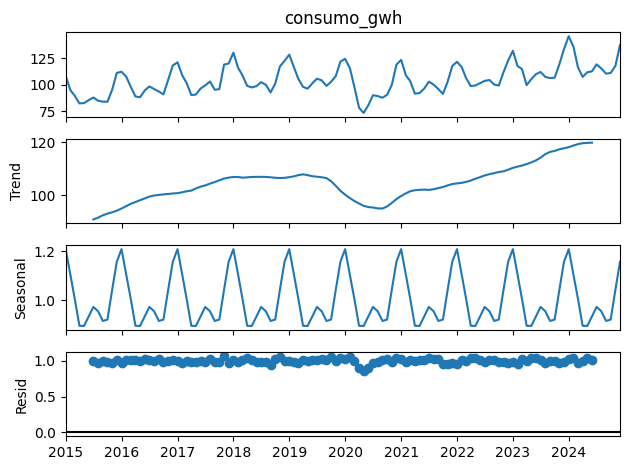

In [17]:
#aca se descompone la serie en sus componentes: tendencia, estacionalidad y residuo
descomposicion = seasonal_decompose(serie, model='multiplicative', period=12 )


# descomposición de la serie
descomposicion.plot()

# guardar y mostrar el gráfico
plt.savefig(figures_dir / "descomposicion_serie.png", dpi=300, bbox_inches="tight")
plt.show()

**Interpretación.** La descomposición muestra una tendencia creciente en el consumo eléctrico, interrumpida por una disminución durante 2020. También se identifica un patrón estacional que se repite anualmente. Los residuos permanecen principalmente alrededor de 1, salvo algunas variaciones puntuales.

**Observed:**

La serie presenta una tendencia general creciente y un patrón que se repite cada año. Se observa además una caída importante alrededor de 2020.

**Trend:**

La tendencia aumenta entre 2015 y 2019, disminuye durante 2020 y posteriormente vuelve a crecer hasta 2024.

**Seasonal:**

Se observa una estacionalidad anual clara, con un patrón similar que se repite aproximadamente cada 12 meses.

**Resid:**

Los residuos se mantienen mayoritariamente cercanos a 1, aunque se observa una alteración más marcada durante 2020.

# 06 ACF y PACF

### Análisis de autocorrelación: ACF y PACF

La ACF y la PACF permiten examinar la dependencia temporal y aportar evidencia para la identificación posterior de modelos de series de tiempo (Hyndman & Athanasopoulos, 2021).

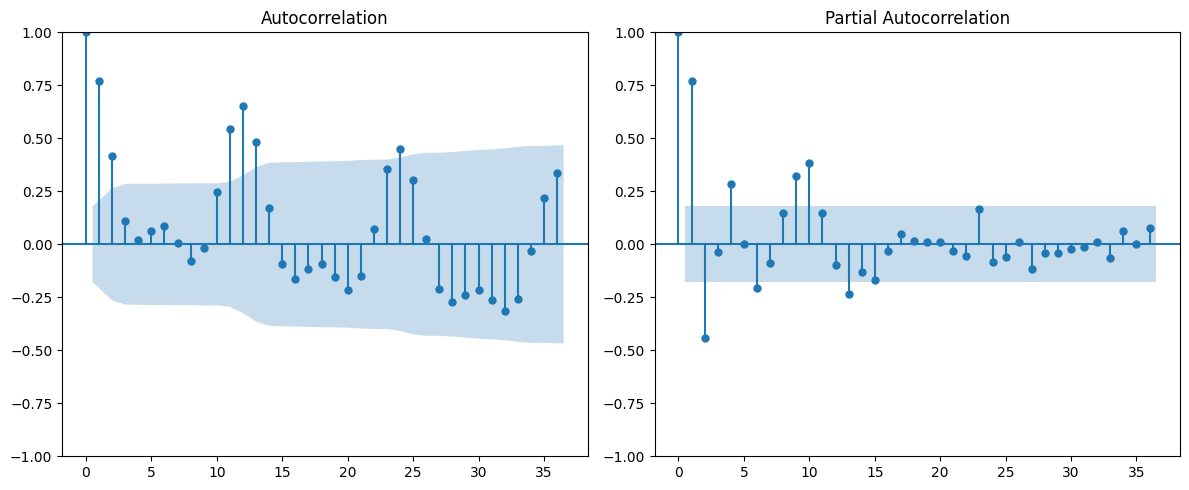

In [18]:
# aca se grafican la ACF y PACF de la serie

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# ACF
plot_acf(serie, ax=axes[0], lags=36)
# PACF
plot_pacf(serie, ax=axes[1], lags=36, method='ywm')

# layout ajustado para evitar solapamiento de elementos

plt.tight_layout()

# guardar y mostrar el gráfico
plt.savefig(figures_dir / "acf_pacf.png", dpi=300, bbox_inches="tight")
plt.show()




**Interpretación** 

La ACF presenta una fuerte dependencia en los primeros rezagos y picos alrededor de los rezagos 12, 24 y 36, lo que evidencia una estructura estacional anual. 

La PACF muestra una influencia importante de los primeros rezagos.

# 07 Interpretación integrada de ACF y PACF:

### ACF: 

En los primeros rezagos la autocorrelación es alta, especialmente en el rezago 1, por lo que existe dependencia temporal entre meses consecutivos.



### Estacionalidad: 

Aparecen picos importantes alrededor de los rezagos 12, 24 y 36, lo que indica un patrón que se repite aproximadamente cada 12 meses.



### PACF: 

Muestra un aporte fuerte en el rezago 1 y algunos rezagos adicionales, lo que confirma que ciertos valores pasados aportan información propia sobre el presente.



### Modelo posterior: 

La presencia de dependencia de corto plazo y estacionalidad anual hace razonable evaluar más adelante modelos como SARIMA.

# 08 Conclusiones

El análisis del consumo eléctrico mensual permitió identificar una tendencia general creciente entre 2015 y 2024, junto con una estacionalidad anual que se repite aproximadamente cada 12 meses.

La descomposición confirmó la presencia de tendencia y estacionalidad, además de una alteración importante alrededor de 2020. Por su parte, la ACF y la PACF evidenciaron dependencia temporal entre las observaciones y picos asociados a la estacionalidad anual.

En conjunto, estos resultados muestran que la serie posee una estructura temporal que debe ser considerada en etapas posteriores de modelamiento. Debido a su componente estacional, modelos como SARIMA podrían evaluarse posteriormente como posibles candidatos.

# 09 Referencias

Hyndman, R. J., & Athanasopoulos, G. (2021). *Forecasting: Principles and practice* (3rd ed.). OTexts. https://otexts.com/fpp3/

Kulkarni, A. R., Shivananda, A., Sharma, N. R., & Kulkarni, A. (2023). *Time series algorithms recipes: Implement machine learning and deep learning techniques with Python*. Apress.

Woodward, W. A., Sadler, B. P., & Robertson, S. (2022). *Time series for data science: Analysis and forecasting*. Chapman & Hall/CRC.

Rosas, H. (2026). *Autocorrelación: cómo medir la dependencia* [Cápsula docente]. Universidad Andrés Bello.

Rosas, H. (2026). *Anatomía de una serie temporal* [Cápsula docente]. Universidad Andrés Bello.

Rosas, H. (2026). *Los mismos números, distinto orden* [Cápsula docente]. Universidad Andrés Bello.

